<a href="https://colab.research.google.com/github/diwashojha17/Ml-lab-works/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Trees and Random Forest Classifier

for Decision Trees

In [42]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [43]:
data = {
    'Day': ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14'],
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temp': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool', 'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'Play Tennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)
print(df)

    Day   Outlook  Temp Humidity    Wind Play Tennis
0    D1     Sunny   Hot     High    Weak          No
1    D2     Sunny   Hot     High  Strong          No
2    D3  Overcast   Hot     High    Weak         Yes
3    D4      Rain  Mild     High    Weak         Yes
4    D5      Rain  Cool   Normal    Weak         Yes
5    D6      Rain  Cool   Normal  Strong          No
6    D7  Overcast  Cool   Normal  Strong         Yes
7    D8     Sunny  Mild     High    Weak          No
8    D9     Sunny  Cool   Normal    Weak         Yes
9   D10      Rain  Mild   Normal    Weak         Yes
10  D11     Sunny  Mild   Normal  Strong         Yes
11  D12  Overcast  Mild     High  Strong         Yes
12  D13  Overcast   Hot   Normal    Weak         Yes
13  D14      Rain  Mild     High  Strong          No


In [24]:
df=df.head()
print(df)

  Day   Outlook  Temp Humidity    Wind Play Tennis
0  D1     Sunny   Hot     High    Weak          No
1  D2     Sunny   Hot     High  Strong          No
2  D3  Overcast   Hot     High    Weak         Yes
3  D4      Rain  Mild     High    Weak         Yes
4  D5      Rain  Cool   Normal    Weak         Yes


In [25]:
df=df.describe()
print(df)

       Day Outlook Temp Humidity  Wind Play Tennis
count    5       5    5        5     5           5
unique   5       3    3        2     2           2
top     D1   Sunny  Hot     High  Weak         Yes
freq     1       2    3        4     4           3


In [26]:
df=df.info()
print(df)

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, count to freq
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Day          4 non-null      object
 1   Outlook      4 non-null      object
 2   Temp         4 non-null      object
 3   Humidity     4 non-null      object
 4   Wind         4 non-null      object
 5   Play Tennis  4 non-null      object
dtypes: object(6)
memory usage: 224.0+ bytes
None


In [44]:
#create data frame
df = pd.DataFrame(data)
print(df)
#define feature and target variable
X=df.drop(['Day','Play Tennis'],axis=1)
y=df['Play Tennis']
#one hot encode the feature
X=pd.get_dummies(X)
print(X)

    Day   Outlook  Temp Humidity    Wind Play Tennis
0    D1     Sunny   Hot     High    Weak          No
1    D2     Sunny   Hot     High  Strong          No
2    D3  Overcast   Hot     High    Weak         Yes
3    D4      Rain  Mild     High    Weak         Yes
4    D5      Rain  Cool   Normal    Weak         Yes
5    D6      Rain  Cool   Normal  Strong          No
6    D7  Overcast  Cool   Normal  Strong         Yes
7    D8     Sunny  Mild     High    Weak          No
8    D9     Sunny  Cool   Normal    Weak         Yes
9   D10      Rain  Mild   Normal    Weak         Yes
10  D11     Sunny  Mild   Normal  Strong         Yes
11  D12  Overcast  Mild     High  Strong         Yes
12  D13  Overcast   Hot   Normal    Weak         Yes
13  D14      Rain  Mild     High  Strong          No
    Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temp_Cool  Temp_Hot  \
0              False         False           True      False      True   
1              False         False           True      Fa

In [45]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Train the DEcision tress classifier
model=DecisionTreeClassifier(criterion='entropy')
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

[Text(0.6666666666666666, 0.9, 'Outlook_Overcast <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]\nclass = Play Tennis '),
 Text(0.5555555555555556, 0.7, 'Humidity_High <= 0.5\nentropy = 1.0\nsamples = 8\nvalue = [4, 4]\nclass = No play Tennis'),
 Text(0.6111111111111112, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'Outlook_Sunny <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]\nclass = Play Tennis '),
 Text(0.2222222222222222, 0.3, 'Wind_Weak <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = No play Tennis'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No play Tennis'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Play Tennis '),
 Text(0.4444444444444444, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Play Tennis '),
 Text(0.7777777777777778, 0.5, 'Wind_Strong <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]\nclass = No play Tennis'),
 Text(0.6666666666666666, 0.3, 'Outl

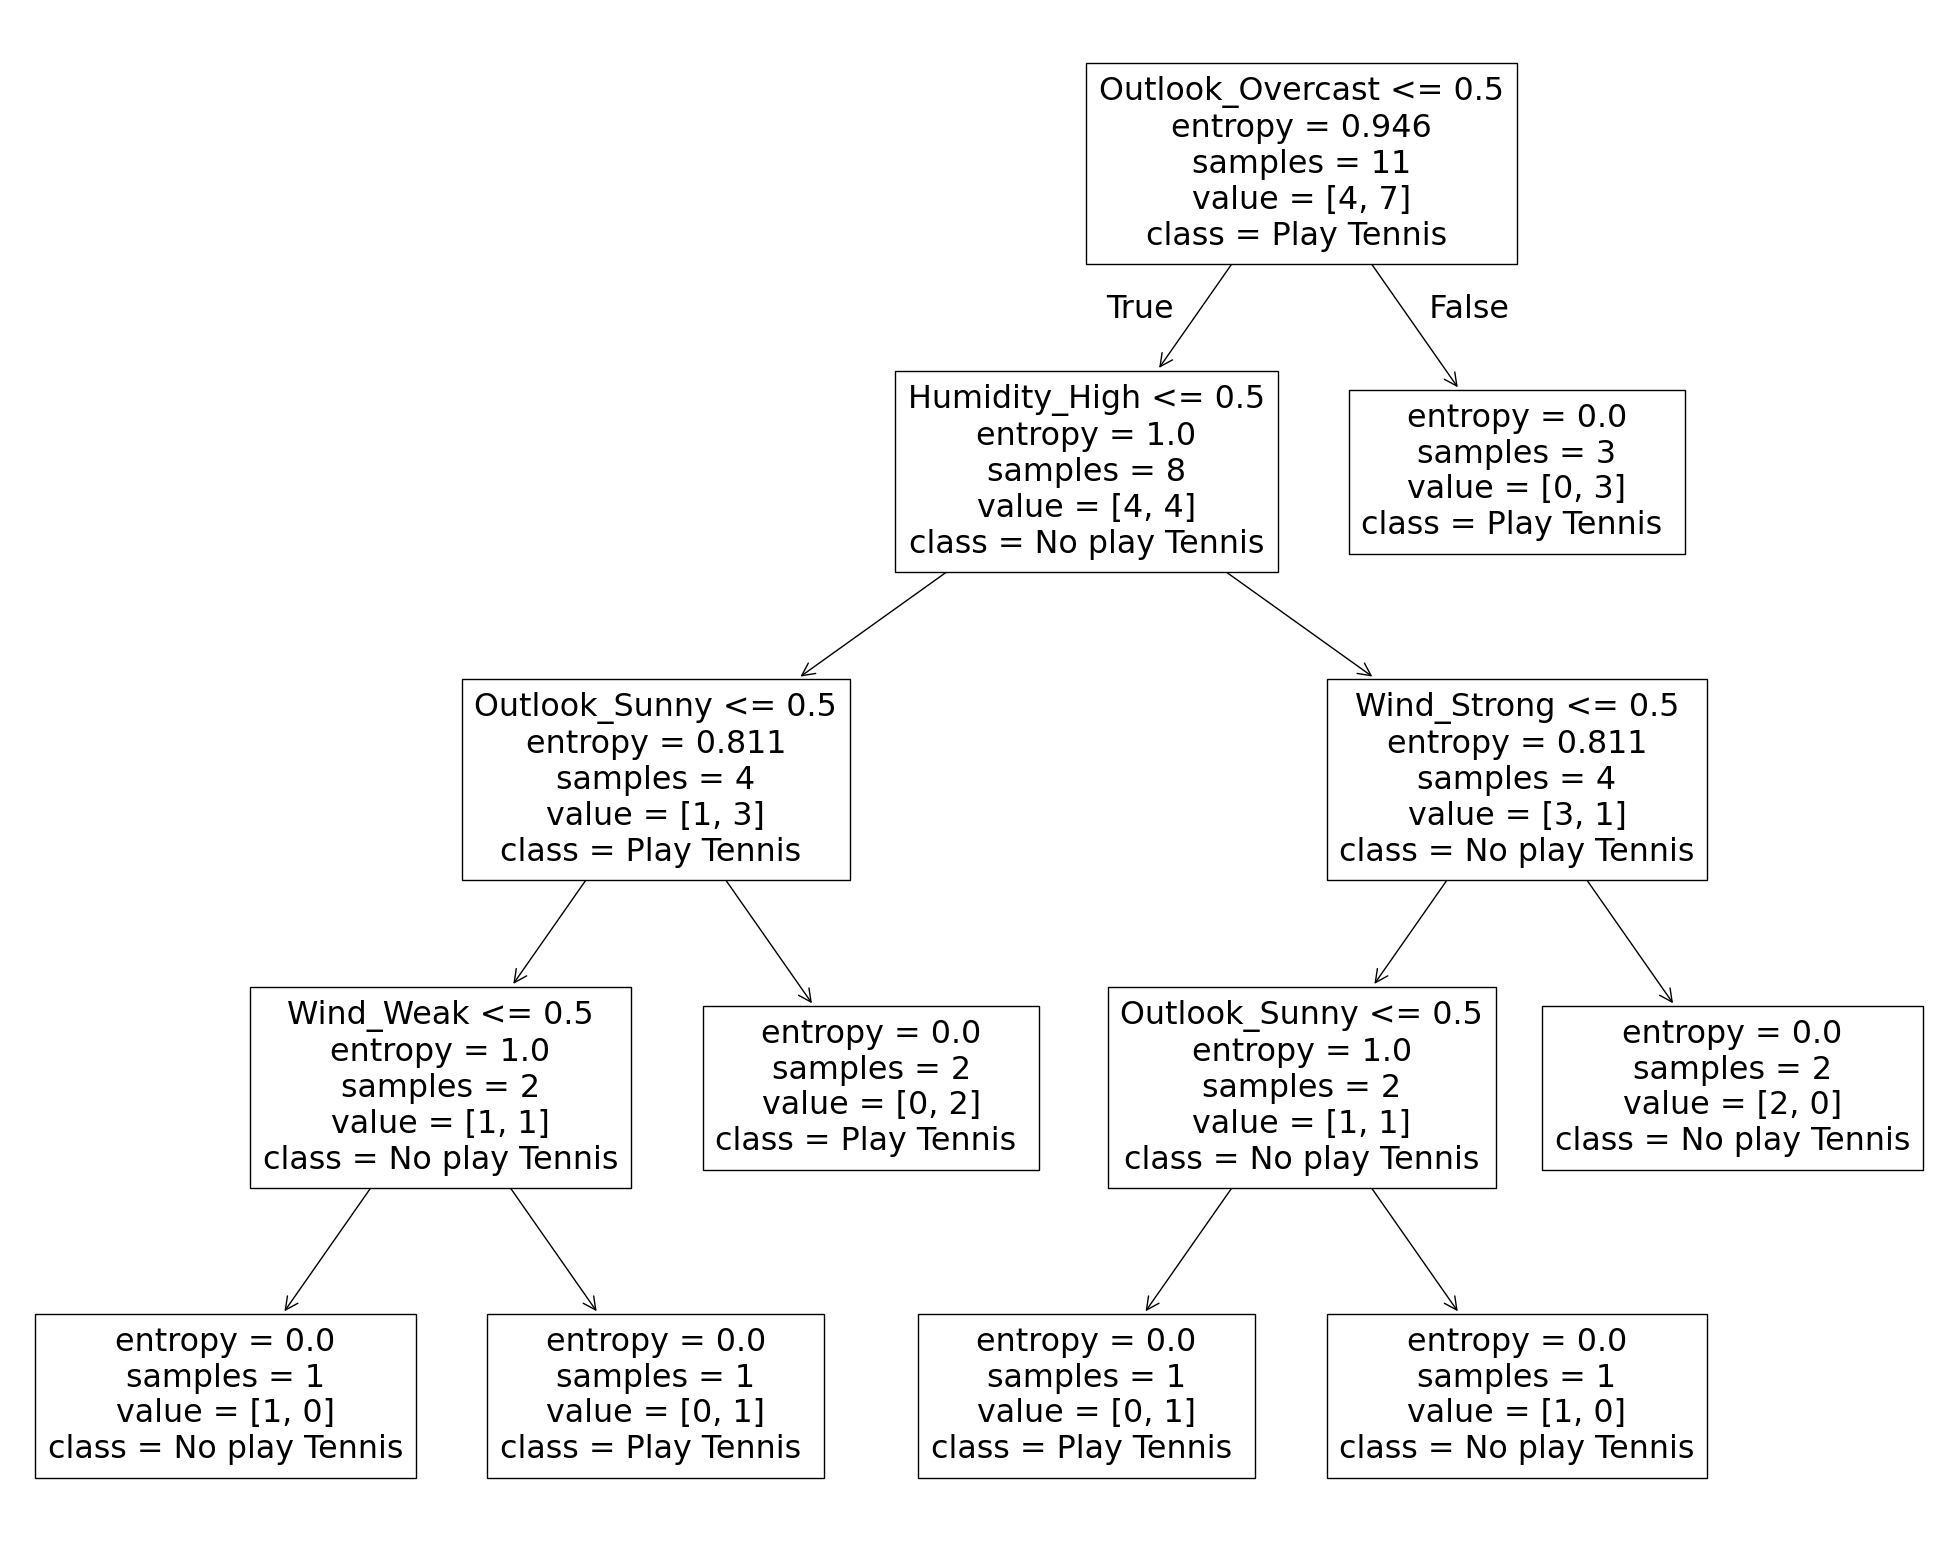

In [46]:
#visualize the tree
import matplotlib.pyplot as plt
plt.figure(figsize=(25,20))
plot_tree(model, feature_names=X.columns, class_names=['No play Tennis','Play Tennis '])


In [47]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1 0]
 [0 2]]
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



for Random Forest Classifier

In [39]:
#Train the Random Forest Classifier:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=10,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [40]:
y_pred=model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1 0]
 [1 1]]
              precision    recall  f1-score   support

          No       0.50      1.00      0.67         1
         Yes       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



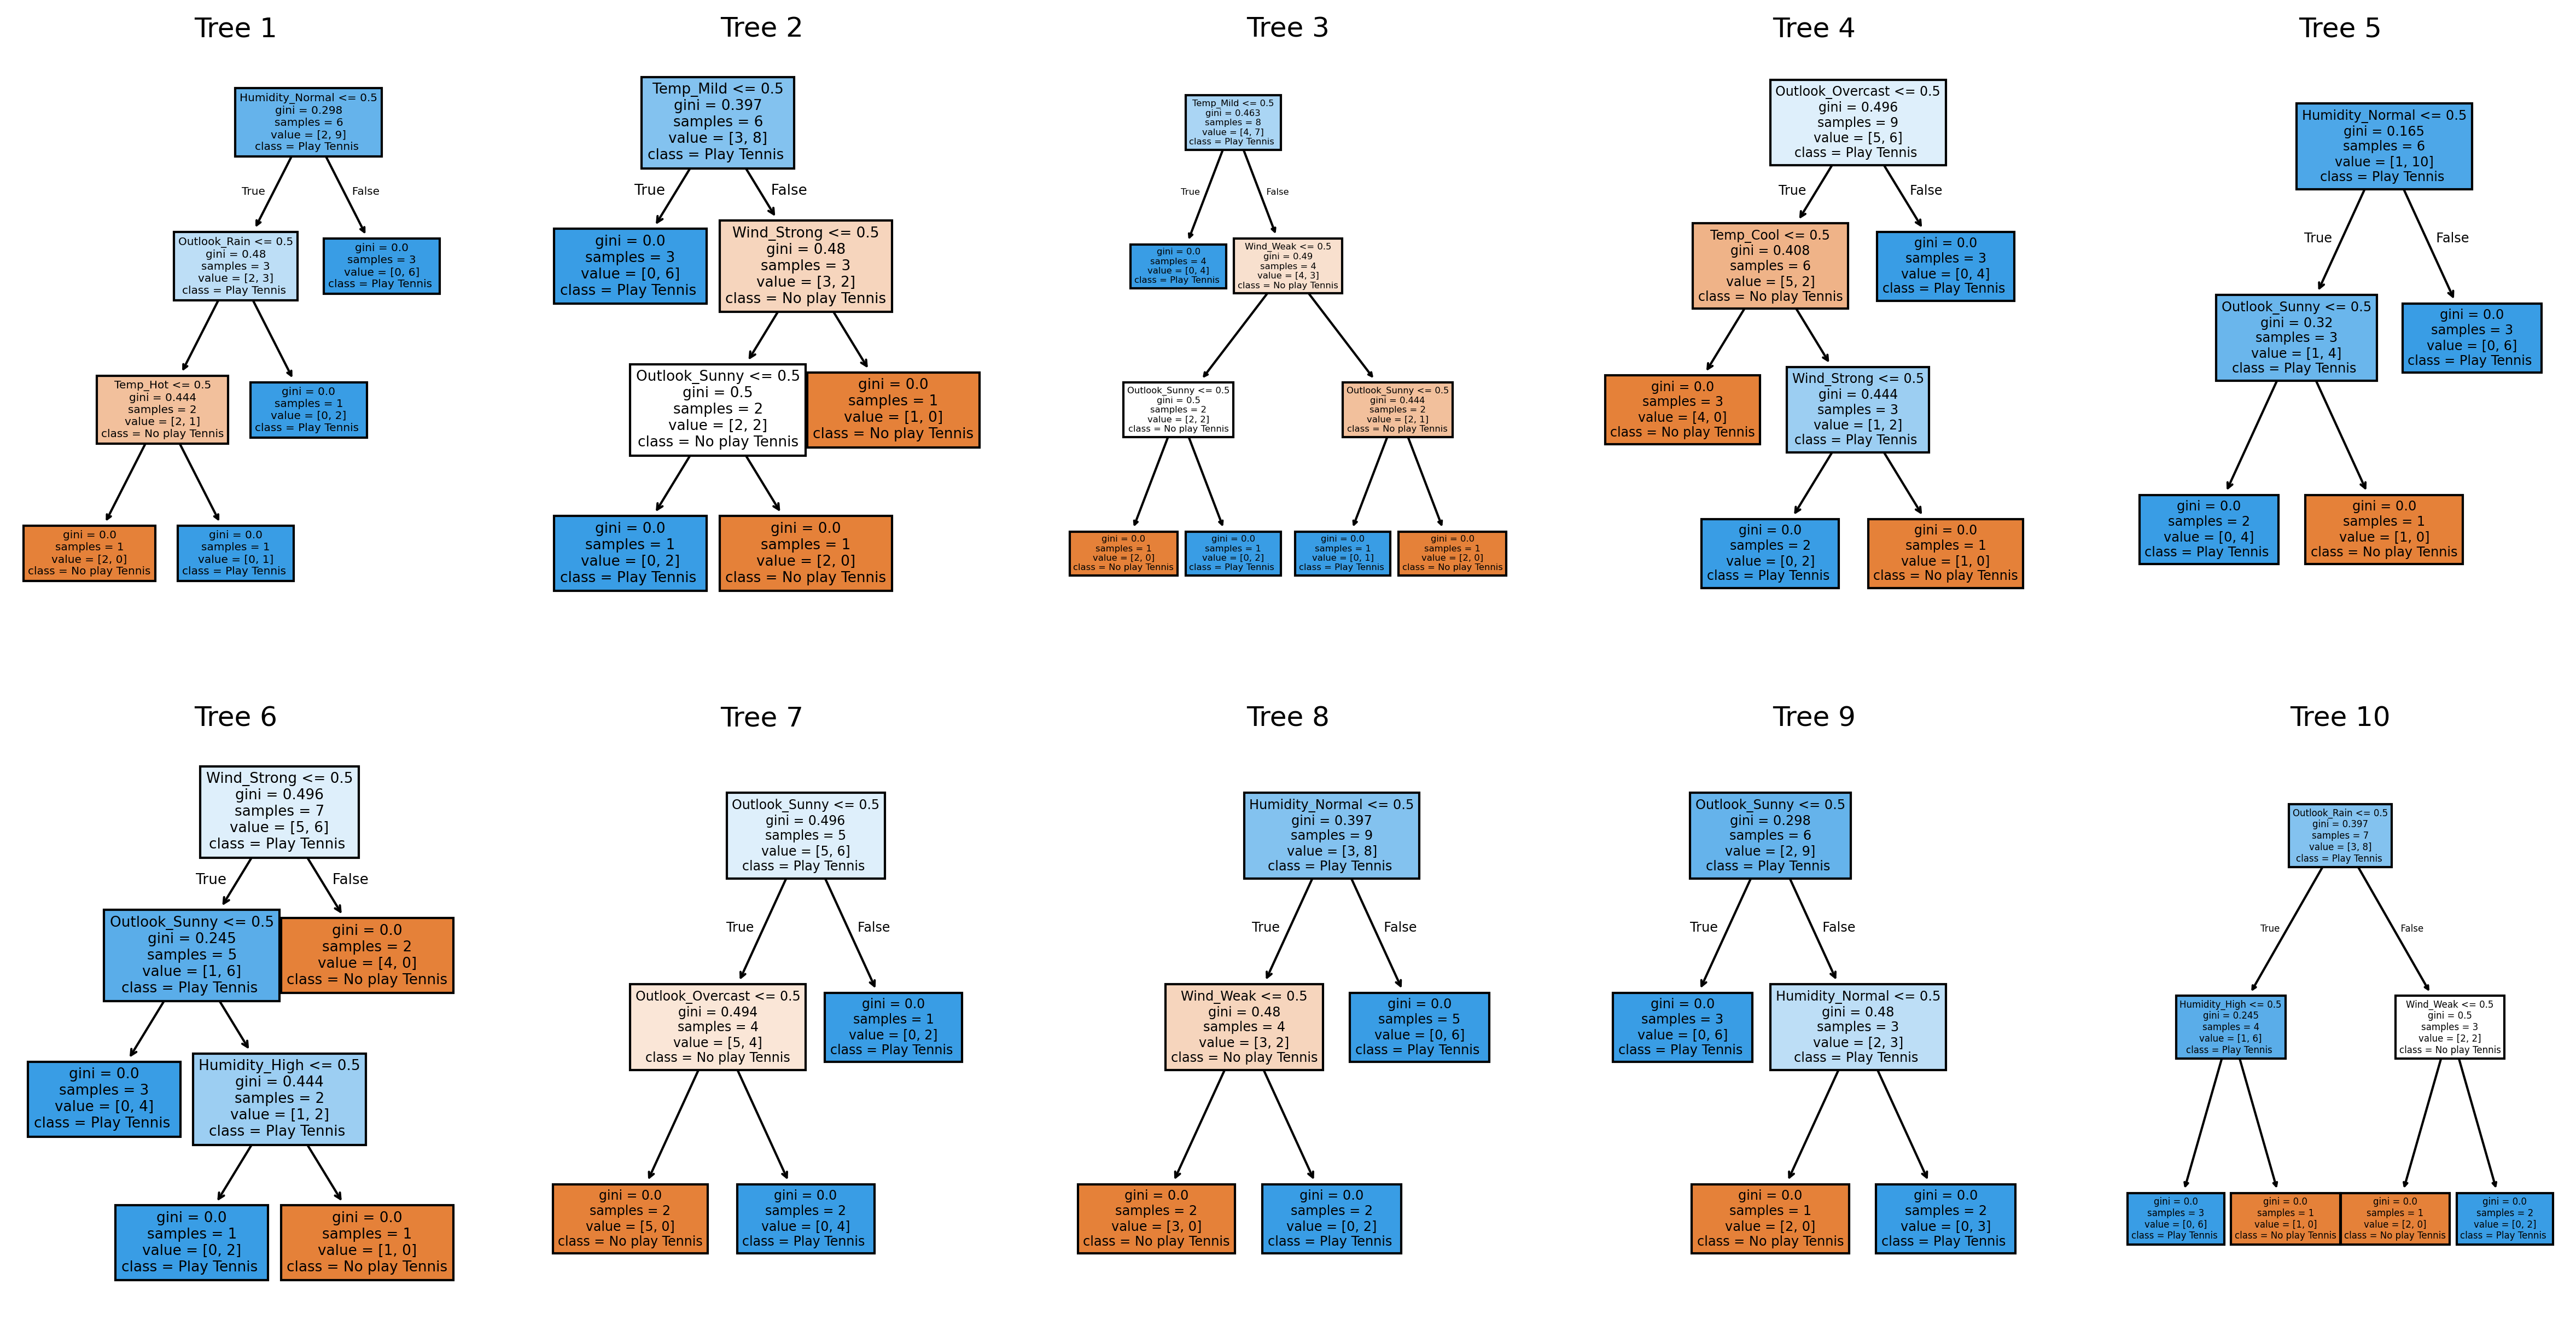

In [41]:
#setup figure with appropriate dimension
num_trees=len(model.estimators_)
cols=5
rows=(num_trees+cols-1)//cols
fig,axes=plt.subplots(rows,cols,figsize=(20,10),dpi=300)
axes=axes.flatten()
for i,tree in enumerate(model.estimators_):
    plot_tree(tree,feature_names=X.columns,class_names=['No play Tennis','Play Tennis '],filled=True ,ax=axes[i])
    axes[i].set_title(f"Tree {i+1}")
